# Adaptation des modèles MNIST à CIFAR-10

Dans ce notebook, on reprend les modèles construits pour MNIST et on les adapte au dataset CIFAR-10.

On réalise deux études :
1. Une étude avec les images converties en niveaux de gris.
2. Une étude avec les images en couleur RGB.

Pour chaque version des données, on teste :
- un modèle linéaire ;
- un MLP à une couche cachée ;
- un MLP à deux couches cachées.

## 1. Importations

In [2]:
# ==================
# Importations
# ==================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

from utils import one_hot_encode

from linear_model import (
    train_linear_model,
    predict,
    accuracy
)

from mlp_model import (
    train_mlp_1_hidden,
    predict_1_hidden,
    train_mlp_2_hidden,
    predict_2_hidden
)

from random_search_utils import (
    create_train_valid_split,
    random_search_linear_model,
    random_search_mlp_1_hidden,
    random_search_mlp_2_hidden,
    results_to_dataframe,
    save_results,
    load_results
)

## 2. Chargement et visualisation de CIFAR-10

In [3]:
# =========================
# Chargement du dataset CIFAR-10
# =========================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Les labels sont donnés sous forme (n, 1), on les transforme en vecteurs simples
y_train = y_train.flatten()
y_test = y_test.flatten()

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

C:\Users\Baptiste\OneDrive - Efrei\Bureau\Baptiste\Efrei\I1\S6 - efrei\ml\projet\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


X_train : (50000, 32, 32, 3)
y_train : (50000,)
X_test : (10000, 32, 32, 3)
y_test : (10000,)


In [4]:
# =========================
# Encodage noms des classes CIFAR-10
# =========================

class_names = [
    "avion",
    "automobile",
    "oiseau",
    "chat",
    "cerf",
    "chien",
    "grenouille",
    "cheval",
    "bateau",
    "camion"
]

for i in range(10):
    print(i, ":", class_names[i])

0 : avion
1 : automobile
2 : oiseau
3 : chat
4 : cerf
5 : chien
6 : grenouille
7 : cheval
8 : bateau
9 : camion


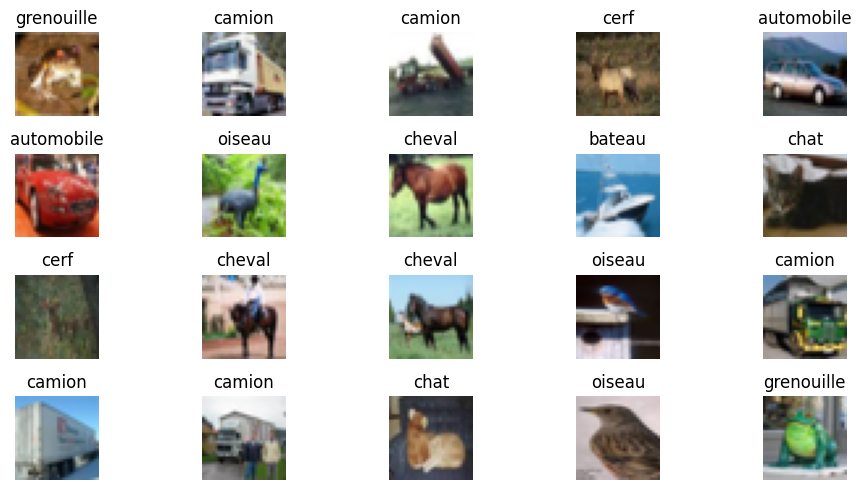

In [5]:
# =============
# Visualisation du dataset
# ============

plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Prétraitement commun

Avant de créer les deux versions des données, on applique les traitements communs.
On normalise d'abord les pixels entre 0 et 1, puis on transforme les labels en one-hot encoding pour pouvoir utiliser la log loss / cross-entropy comme dans la partie MNIST.

In [6]:
# =========================
# Normalisation des pixels
# =========================

X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

print("Valeur min train :", X_train.min())
print("Valeur max train :", X_train.max())
print("Valeur min test :", X_test.min())
print("Valeur max test :", X_test.max())

Valeur min train : 0.0
Valeur max train : 1.0
Valeur min test : 0.0
Valeur max test : 1.0


In [7]:
# =========================
# One-hot encoding des labels
# =========================

Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

print("Y_train :", Y_train.shape)
print("Y_test :", Y_test.shape)

Y_train : (50000, 10)
Y_test : (10000, 10)


## 4. Première étude : images en niveaux de gris

Dans cette première étude, on transforme les images CIFAR-10 en niveaux de gris.
L'objectif est de tester nos modèles précédents sur des images plus simples que les images RGB, mais plus complexes que MNIST.
Après la conversion, chaque image a une taille de 32×32 pixels. On l'aplatit ensuite en un vecteur de taille 1024.

### 4.1 Prétraitement des images en niveaux de gris

In [8]:
# =========================
# Conversion RGB vers niveaux de gris
# =========================

X_train_gray = (
    0.299 * X_train[:, :, :, 0]
    + 0.587 * X_train[:, :, :, 1]
    + 0.114 * X_train[:, :, :, 2]
)

X_test_gray = (
    0.299 * X_test[:, :, :, 0]
    + 0.587 * X_test[:, :, :, 1]
    + 0.114 * X_test[:, :, :, 2]
)

print("X_train_gray :", X_train_gray.shape)
print("X_test_gray :", X_test_gray.shape)


# =========================
# Aplatissement grayscale : 32 x 32 = 1024
# =========================

X_train_gray_flat = X_train_gray.reshape(X_train_gray.shape[0], 32 * 32)
X_test_gray_flat = X_test_gray.reshape(X_test_gray.shape[0], 32 * 32)

print("X_train_gray_flat :", X_train_gray_flat.shape)
print("X_test_gray_flat :", X_test_gray_flat.shape)


# =========================
# Split train / validation
# =========================

X_train_gray_sub, Y_train_gray_sub, y_train_gray_sub, X_valid_gray, Y_valid_gray, y_valid_gray = create_train_valid_split(
    X_train_gray_flat,
    Y_train,
    y_train,
    valid_size=5000
)

print("X_train_gray_sub :", X_train_gray_sub.shape)
print("Y_train_gray_sub :", Y_train_gray_sub.shape)
print("X_valid_gray :", X_valid_gray.shape)
print("Y_valid_gray :", Y_valid_gray.shape)

X_train_gray : (50000, 32, 32)
X_test_gray : (10000, 32, 32)
X_train_gray_flat : (50000, 1024)
X_test_gray_flat : (10000, 1024)
X_train_gray_sub : (45000, 1024)
Y_train_gray_sub : (45000, 10)
X_valid_gray : (5000, 1024)
Y_valid_gray : (5000, 10)


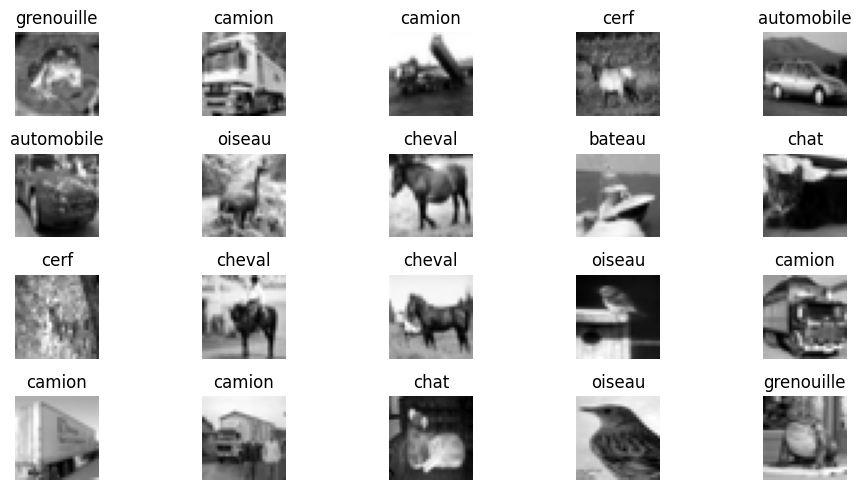

In [9]:
# =========================
# Visualisation des images en niveaux de gris
# =========================

plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_gray[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4.2 Modèle linéaire sur les images en niveaux de gris

On commence par tester le modèle linéaire sur les images CIFAR-10 converties en niveaux de gris.
Chaque image est représentée par un vecteur de taille 1024. Ce modèle sert de baseline, comme dans la partie MNIST.

In [10]:
# =========================
# Modèle linéaire - CIFAR grayscale
# =========================

A_gray, b_gray, loss_linear_gray = train_linear_model(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    num_classes=10,
    learning_rate=0.5,
    epochs=300
)

# train Accuracy
y_pred_train_linear_gray = predict(X_train_gray_sub, A_gray, b_gray)
acc_train_linear_gray = accuracy(y_train_gray_sub, y_pred_train_linear_gray)

# Accuracy validation
y_pred_valid_linear_gray = predict(X_valid_gray, A_gray, b_gray)
acc_valid_linear_gray = accuracy(y_valid_gray, y_pred_valid_linear_gray)

# Accuracy test
y_pred_test_linear_gray = predict(X_test_gray_flat, A_gray, b_gray)
acc_test_linear_gray = accuracy(y_test, y_pred_test_linear_gray)

print("Train accuracy :", acc_train_linear_gray)
print("Validation accuracy :", acc_valid_linear_gray)
print("Test accuracy :", acc_test_linear_gray)
print("Taux d'erreur test :", 1 - acc_test_linear_gray)

Train accuracy : 0.11295555555555556
Validation accuracy : 0.116
Test accuracy : 0.1143
Taux d'erreur test : 0.8857


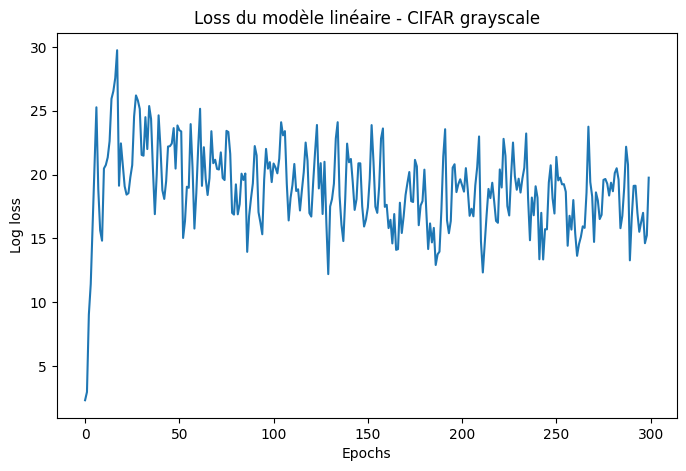

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(loss_linear_gray)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du modèle linéaire - CIFAR grayscale")

plt.show()

Le learning rate (et eventuellement le nombre d'epoch) semble trop grand ce qui cree beaucoup d'instabilite. On test donc differents learning rate ci-dessous.


Learning rate : 0.1
Train accuracy : 0.22084444444444445
Validation accuracy : 0.2204
Final loss : 2.282824284282696

Learning rate : 0.05
Train accuracy : 0.27597777777777777
Validation accuracy : 0.2762
Final loss : 2.0647120998806696

Learning rate : 0.02
Train accuracy : 0.2547333333333333
Validation accuracy : 0.2514
Final loss : 2.1070680500242607

Learning rate : 0.01
Train accuracy : 0.23613333333333333
Validation accuracy : 0.2358
Final loss : 2.1465263273951027


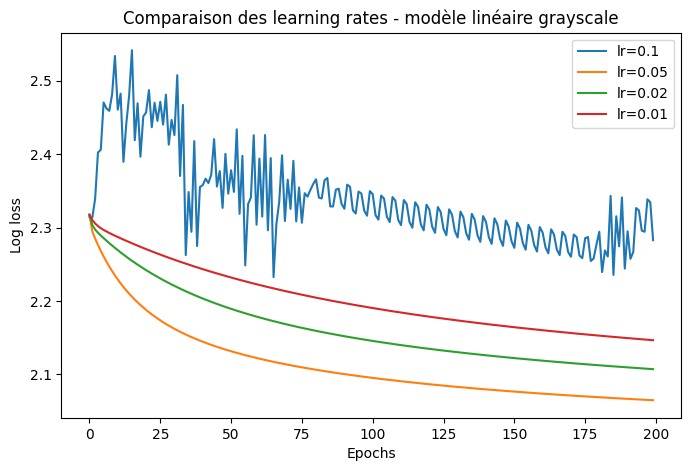

In [13]:
# Test de plusieurs lr


learning_rates = [0.1, 0.05, 0.02, 0.01]

results_lr_linear_gray = []

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    print("\n==============================")
    print("Learning rate :", lr)
    print("==============================")

    A_tmp, b_tmp, loss_tmp = train_linear_model(
        X_train_gray_sub,
        Y_train_gray_sub,
        input_dim=1024,
        num_classes=10,
        learning_rate=lr,
        epochs=200
    )

    y_pred_train_tmp = predict(X_train_gray_sub, A_tmp, b_tmp)
    y_pred_valid_tmp = predict(X_valid_gray, A_tmp, b_tmp)

    acc_train_tmp = accuracy(y_train_gray_sub, y_pred_train_tmp)
    acc_valid_tmp = accuracy(y_valid_gray, y_pred_valid_tmp)

    print("Train accuracy :", acc_train_tmp)
    print("Validation accuracy :", acc_valid_tmp)
    print("Final loss :", loss_tmp[-1])

    results_lr_linear_gray.append({
        "learning_rate": lr,
        "train_accuracy": acc_train_tmp,
        "valid_accuracy": acc_valid_tmp,
        "final_loss": loss_tmp[-1],
        "A": A_tmp,
        "b": b_tmp,
        "loss_history": loss_tmp
    })

    plt.plot(loss_tmp, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Comparaison des learning rates - modèle linéaire grayscale")
plt.legend()
plt.show()

Le learning rate le plus adapte semble etre lr = 0.05, donc on entraine un modele final pour ce learning rate.

In [27]:
# =========================
# Modèle linéaire grayscale final
# =========================

A_gray, b_gray, loss_linear_gray = train_linear_model(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    num_classes=10,
    learning_rate=0.05,
    epochs=600
)

# Accuracy train
y_pred_train_linear_gray = predict(X_train_gray_sub, A_gray, b_gray)
acc_train_linear_gray = accuracy(y_train_gray_sub, y_pred_train_linear_gray)

# Accuracy validation
y_pred_valid_linear_gray = predict(X_valid_gray, A_gray, b_gray)
acc_valid_linear_gray = accuracy(y_valid_gray, y_pred_valid_linear_gray)

# Accuracy test
y_pred_test_linear_gray = predict(X_test_gray_flat, A_gray, b_gray)
acc_test_linear_gray = accuracy(y_test, y_pred_test_linear_gray)

print("Train accuracy :", acc_train_linear_gray)
print("Validation accuracy :", acc_valid_linear_gray)
print("Test accuracy :", acc_test_linear_gray)
print("Taux d'erreur test :", 1 - acc_test_linear_gray)

Train accuracy : 0.2950888888888889
Validation accuracy : 0.2928
Test accuracy : 0.2935
Taux d'erreur test : 0.7065


Le modèle linéaire sur les images en niveaux de gris atteint environ 28 à 30 % d'accuracy. Ce résultat est nettement inférieur à ceux obtenus sur MNIST, ce qui est attendu car CIFAR-10 contient des images réelles beaucoup plus complexes.

Même si le modèle apprend mieux que le hasard, qui serait autour de 10 % pour 10 classes, il reste limité car les images sont aplaties en vecteurs et l'information spatiale de l'image n'est pas réellement exploitée.

### 4.3 MLP à une couche cachée sur les images en niveaux de gris

On teste maintenant un MLP avec une couche cachée. L'objectif est de voir si l'ajout d'une non-linéarité permet d'améliorer les résultats par rapport au modèle linéaire.

Comme cette partie reste préliminaire, on ne fait pas une random search complète. On teste seulement quelques learning rates et tailles de couche cachée afin d'obtenir un modèle correct sans y passer trop de temps.


hidden_dim=256, learning_rate=0.05
Train accuracy : 0.29355555555555557
Validation accuracy : 0.2872
Final loss : 2.0132902465234834

hidden_dim=512, learning_rate=0.05
Train accuracy : 0.3019777777777778
Validation accuracy : 0.2956
Final loss : 2.002347113646766

hidden_dim=256, learning_rate=0.02
Train accuracy : 0.2576
Validation accuracy : 0.2556
Final loss : 2.0860936653788795

hidden_dim=512, learning_rate=0.02
Train accuracy : 0.27068888888888887
Validation accuracy : 0.2614
Final loss : 2.066785997701828


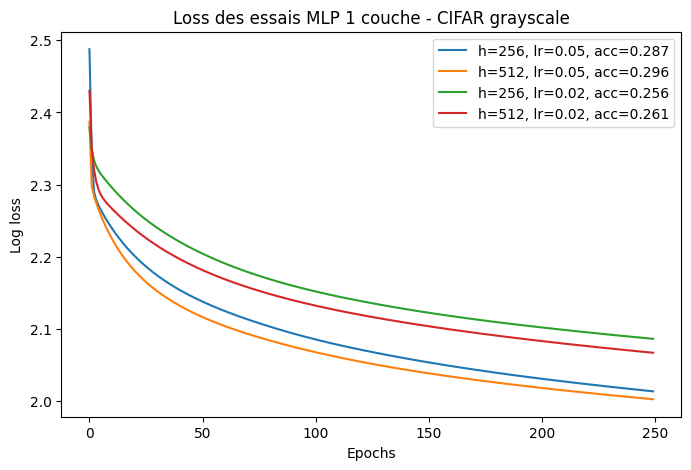

In [15]:
# =========================
# Tests rapides - MLP 1 couche grayscale
# =========================

configs_mlp1_gray = [
    {"hidden_dim": 256, "learning_rate": 0.05},
    {"hidden_dim": 512, "learning_rate": 0.05},
    {"hidden_dim": 256, "learning_rate": 0.02},
    {"hidden_dim": 512, "learning_rate": 0.02},
]

results_mlp1_gray = []

plt.figure(figsize=(8, 5))

for config in configs_mlp1_gray:
    hidden_dim = config["hidden_dim"]
    lr = config["learning_rate"]

    print("\n==============================")
    print(f"hidden_dim={hidden_dim}, learning_rate={lr}")
    print("==============================")

    A1, b1, A2, b2, loss_history = train_mlp_1_hidden(
        X_train_gray_sub,
        Y_train_gray_sub,
        input_dim=1024,
        hidden_dim=hidden_dim,
        num_classes=10,
        learning_rate=lr,
        epochs=250
    )

    y_pred_train = predict_1_hidden(X_train_gray_sub, A1, b1, A2, b2)
    y_pred_valid = predict_1_hidden(X_valid_gray, A1, b1, A2, b2)

    acc_train = accuracy(y_train_gray_sub, y_pred_train)
    acc_valid = accuracy(y_valid_gray, y_pred_valid)

    print("Train accuracy :", acc_train)
    print("Validation accuracy :", acc_valid)
    print("Final loss :", loss_history[-1])

    results_mlp1_gray.append({
        "model": "MLP 1 hidden grayscale",
        "hidden_dim": hidden_dim,
        "learning_rate": lr,
        "epochs": 250,
        "train_accuracy": acc_train,
        "valid_accuracy": acc_valid,
        "final_loss": loss_history[-1],
        "time_sec": None,
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2,
        "loss_history": loss_history
    })

    plt.plot(loss_history, label=f"h={hidden_dim}, lr={lr}, acc={acc_valid:.3f}")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des essais MLP 1 couche - CIFAR grayscale")
plt.legend()
plt.show()


hidden_dim=512, learning_rate=0.1
Train accuracy : 0.3148
Validation accuracy : 0.3088
Final loss : 1.945705303976604

hidden_dim=256, learning_rate=0.1
Train accuracy : 0.3127333333333333
Validation accuracy : 0.313
Final loss : 1.9713011498997763


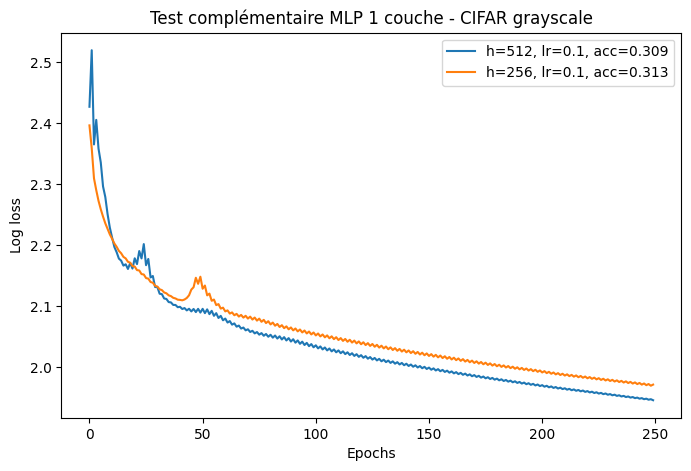

In [16]:
# =========================
# Petit test complémentaire - MLP 1 couche grayscale avec lr plus élevé
# =========================

configs_mlp1_gray_extra = [
    {"hidden_dim": 512, "learning_rate": 0.1},
    {"hidden_dim": 256, "learning_rate": 0.1},
]

results_mlp1_gray_extra = []

plt.figure(figsize=(8, 5))

for config in configs_mlp1_gray_extra:
    hidden_dim = config["hidden_dim"]
    lr = config["learning_rate"]

    print("\n==============================")
    print(f"hidden_dim={hidden_dim}, learning_rate={lr}")
    print("==============================")

    A1, b1, A2, b2, loss_history = train_mlp_1_hidden(
        X_train_gray_sub,
        Y_train_gray_sub,
        input_dim=1024,
        hidden_dim=hidden_dim,
        num_classes=10,
        learning_rate=lr,
        epochs=250
    )

    y_pred_train = predict_1_hidden(X_train_gray_sub, A1, b1, A2, b2)
    y_pred_valid = predict_1_hidden(X_valid_gray, A1, b1, A2, b2)

    acc_train = accuracy(y_train_gray_sub, y_pred_train)
    acc_valid = accuracy(y_valid_gray, y_pred_valid)

    print("Train accuracy :", acc_train)
    print("Validation accuracy :", acc_valid)
    print("Final loss :", loss_history[-1])

    results_mlp1_gray_extra.append({
        "model": "MLP 1 hidden grayscale",
        "hidden_dim": hidden_dim,
        "learning_rate": lr,
        "epochs": 250,
        "train_accuracy": acc_train,
        "valid_accuracy": acc_valid,
        "final_loss": loss_history[-1],
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2,
        "loss_history": loss_history
    })

    plt.plot(loss_history, label=f"h={hidden_dim}, lr={lr}, acc={acc_valid:.3f}")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Test complémentaire MLP 1 couche - CIFAR grayscale")
plt.legend()
plt.show()

lr = 0.1 a l'air plus adapte (car converge plus rapidement en restant relativement stable) et on remarque d'apres la courbe qu'il ne semble pas necessaire d'augmenter le nombre de neurones de la couche cachee.

In [17]:
# =========================
# Modèle final MLP 1 couche grayscale
# =========================

A1_mlp1_gray, b1_mlp1_gray, A2_mlp1_gray, b2_mlp1_gray, loss_mlp1_gray_final = train_mlp_1_hidden(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    hidden_dim=256,
    num_classes=10,
    learning_rate=0.1,
    epochs=400
)

# Accuracy train
y_pred_train_mlp1_gray = predict_1_hidden(
    X_train_gray_sub,
    A1_mlp1_gray,
    b1_mlp1_gray,
    A2_mlp1_gray,
    b2_mlp1_gray
)

acc_train_mlp1_gray = accuracy(y_train_gray_sub, y_pred_train_mlp1_gray)

# Accuracy validation
y_pred_valid_mlp1_gray = predict_1_hidden(
    X_valid_gray,
    A1_mlp1_gray,
    b1_mlp1_gray,
    A2_mlp1_gray,
    b2_mlp1_gray
)

acc_valid_mlp1_gray = accuracy(y_valid_gray, y_pred_valid_mlp1_gray)

# Accuracy test
y_pred_test_mlp1_gray = predict_1_hidden(
    X_test_gray_flat,
    A1_mlp1_gray,
    b1_mlp1_gray,
    A2_mlp1_gray,
    b2_mlp1_gray
)

acc_test_mlp1_gray = accuracy(y_test, y_pred_test_mlp1_gray)

print("Train accuracy :", acc_train_mlp1_gray)
print("Validation accuracy :", acc_valid_mlp1_gray)
print("Test accuracy :", acc_test_mlp1_gray)
print("Taux d'erreur test :", 1 - acc_test_mlp1_gray)

Train accuracy : 0.3247111111111111
Validation accuracy : 0.3178
Test accuracy : 0.3173
Taux d'erreur test : 0.6827


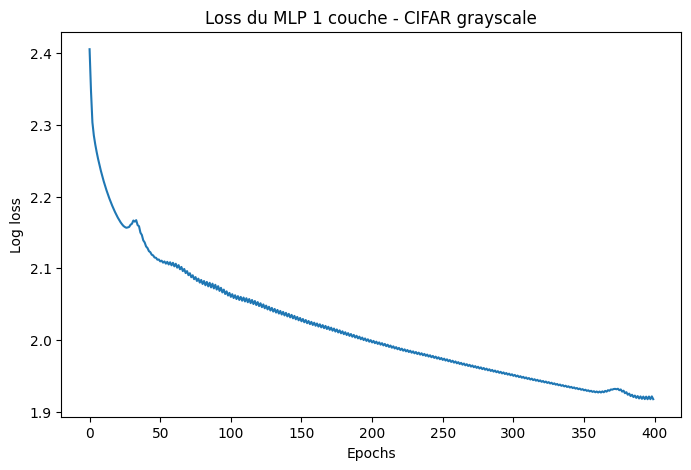

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(loss_mlp1_gray_final)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du MLP 1 couche - CIFAR grayscale")

plt.show()

In [19]:
# =========================
# Test amélioration MLP 1 couche grayscale
# =========================

A1_test, b1_test, A2_test, b2_test, loss_test = train_mlp_1_hidden(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    hidden_dim=512,
    num_classes=10,
    learning_rate=0.1,
    epochs=400
)

y_pred_train_test = predict_1_hidden(
    X_train_gray_sub,
    A1_test,
    b1_test,
    A2_test,
    b2_test
)

y_pred_valid_test = predict_1_hidden(
    X_valid_gray,
    A1_test,
    b1_test,
    A2_test,
    b2_test
)

y_pred_test_test = predict_1_hidden(
    X_test_gray_flat,
    A1_test,
    b1_test,
    A2_test,
    b2_test
)

acc_train_test = accuracy(y_train_gray_sub, y_pred_train_test)
acc_valid_test = accuracy(y_valid_gray, y_pred_valid_test)
acc_test_test = accuracy(y_test, y_pred_test_test)

print("Train accuracy :", acc_train_test)
print("Validation accuracy :", acc_valid_test)
print("Test accuracy :", acc_test_test)
print("Taux d'erreur test :", 1 - acc_test_test)

Train accuracy : 0.3345111111111111
Validation accuracy : 0.329
Test accuracy : 0.3306
Taux d'erreur test : 0.6694


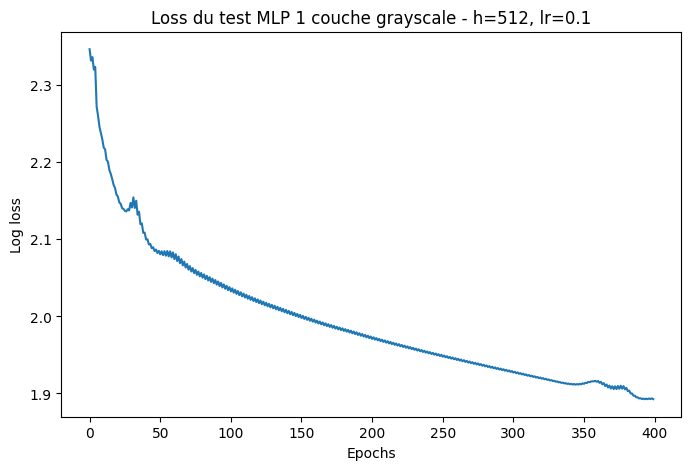

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(loss_test)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du test MLP 1 couche grayscale - h=512, lr=0.1")

plt.show()

In [21]:
# =========================
# Test amélioration MLP 1 couche grayscale - plus d'epochs
# =========================

A1_test2, b1_test2, A2_test2, b2_test2, loss_test2 = train_mlp_1_hidden(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    hidden_dim=512,
    num_classes=10,
    learning_rate=0.1,
    epochs=600
)

# Accuracy train
y_pred_train_test2 = predict_1_hidden(
    X_train_gray_sub,
    A1_test2,
    b1_test2,
    A2_test2,
    b2_test2
)

# Accuracy validation
y_pred_valid_test2 = predict_1_hidden(
    X_valid_gray,
    A1_test2,
    b1_test2,
    A2_test2,
    b2_test2
)

# Accuracy test
y_pred_test_test2 = predict_1_hidden(
    X_test_gray_flat,
    A1_test2,
    b1_test2,
    A2_test2,
    b2_test2
)

acc_train_test2 = accuracy(y_train_gray_sub, y_pred_train_test2)
acc_valid_test2 = accuracy(y_valid_gray, y_pred_valid_test2)
acc_test_test2 = accuracy(y_test, y_pred_test_test2)

print("Train accuracy :", acc_train_test2)
print("Validation accuracy :", acc_valid_test2)
print("Test accuracy :", acc_test_test2)
print("Taux d'erreur test :", 1 - acc_test_test2)

Train accuracy : 0.35388888888888886
Validation accuracy : 0.3436
Test accuracy : 0.3451
Taux d'erreur test : 0.6549


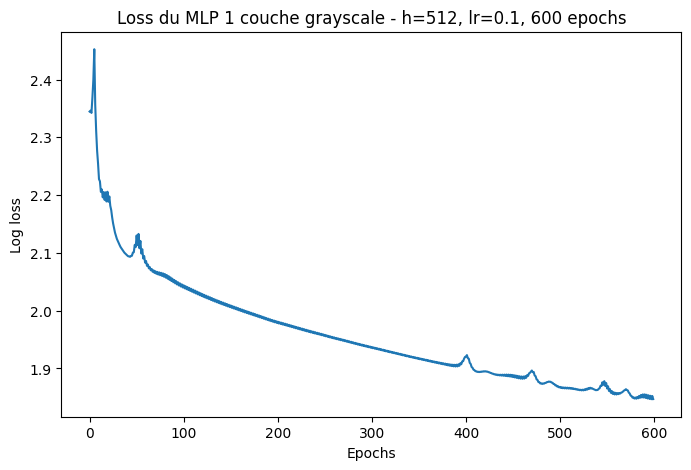

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(loss_test2)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du MLP 1 couche grayscale - h=512, lr=0.1, 600 epochs")

plt.show()

En augmentant le nombre d'epochs à 600, le MLP à une couche cachée progresse encore et atteint environ 34,5 % d'accuracy sur le test set. La loss continue de diminuer et l'écart entre train et test reste faible. Nous gardons donc cette configuration comme meilleur modèle à une couche cachée sur les images en niveaux de gris.

### 4.4 MLP à deux couches cachées sur les images en niveaux de gris

On teste maintenant un MLP avec deux couches cachées.
L'objectif est de voir si l'ajout d'une deuxième couche permet d'améliorer les résultats par rapport au MLP à une couche.

Comme pour le modèle précédent, on ne cherche pas à faire une optimisation complète. On teste seulement quelques configurations cohérentes afin d'obtenir une comparaison rapide.


h1=512, h2=256, learning_rate=0.1
Train accuracy : 0.33166666666666667
Validation accuracy : 0.3208
Final loss : 1.8599788597981013

h1=512, h2=128, learning_rate=0.1
Train accuracy : 0.3445111111111111
Validation accuracy : 0.3312
Final loss : 1.868858559397486

h1=256, h2=128, learning_rate=0.1
Train accuracy : 0.33366666666666667
Validation accuracy : 0.3276
Final loss : 1.8896327333193264

h1=512, h2=256, learning_rate=0.05
Train accuracy : 0.3292
Validation accuracy : 0.3202
Final loss : 1.9206251605397828


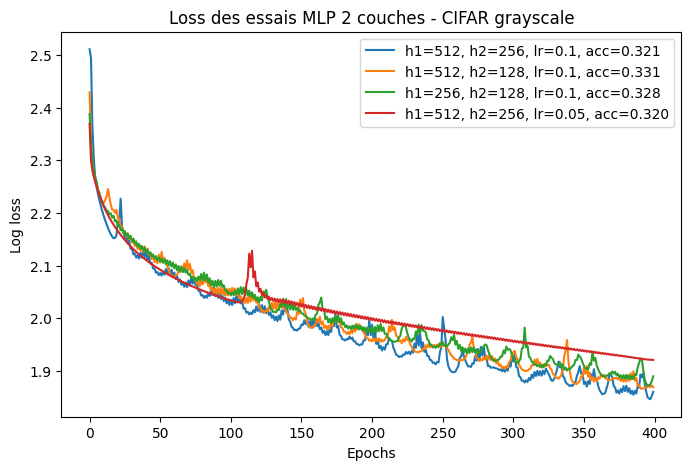

In [23]:
# =========================
# Tests rapides - MLP 2 couches grayscale
# =========================

configs_mlp2_gray = [
    {"hidden_dim1": 512, "hidden_dim2": 256, "learning_rate": 0.1},
    {"hidden_dim1": 512, "hidden_dim2": 128, "learning_rate": 0.1},
    {"hidden_dim1": 256, "hidden_dim2": 128, "learning_rate": 0.1},
    {"hidden_dim1": 512, "hidden_dim2": 256, "learning_rate": 0.05},
]

results_mlp2_gray = []

plt.figure(figsize=(8, 5))

for config in configs_mlp2_gray:
    hidden_dim1 = config["hidden_dim1"]
    hidden_dim2 = config["hidden_dim2"]
    lr = config["learning_rate"]

    print("\n==============================")
    print(f"h1={hidden_dim1}, h2={hidden_dim2}, learning_rate={lr}")
    print("==============================")

    A1, b1, A2, b2, A3, b3, loss_history = train_mlp_2_hidden(
        X_train_gray_sub,
        Y_train_gray_sub,
        input_dim=1024,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        num_classes=10,
        learning_rate=lr,
        epochs=400
    )

    y_pred_train = predict_2_hidden(
        X_train_gray_sub,
        A1, b1,
        A2, b2,
        A3, b3
    )

    y_pred_valid = predict_2_hidden(
        X_valid_gray,
        A1, b1,
        A2, b2,
        A3, b3
    )

    acc_train = accuracy(y_train_gray_sub, y_pred_train)
    acc_valid = accuracy(y_valid_gray, y_pred_valid)

    print("Train accuracy :", acc_train)
    print("Validation accuracy :", acc_valid)
    print("Final loss :", loss_history[-1])

    results_mlp2_gray.append({
        "model": "MLP 2 hidden grayscale",
        "hidden_dim1": hidden_dim1,
        "hidden_dim2": hidden_dim2,
        "learning_rate": lr,
        "epochs": 400,
        "train_accuracy": acc_train,
        "valid_accuracy": acc_valid,
        "final_loss": loss_history[-1],
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2,
        "A3": A3,
        "b3": b3,
        "loss_history": loss_history
    })

    plt.plot(
        loss_history,
        label=f"h1={hidden_dim1}, h2={hidden_dim2}, lr={lr}, acc={acc_valid:.3f}"
    )

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des essais MLP 2 couches - CIFAR grayscale")
plt.legend()
plt.show()

In [24]:
best_mlp2_gray = max(results_mlp2_gray, key=lambda r: r["valid_accuracy"])

y_pred_test_mlp2_gray = predict_2_hidden(
    X_test_gray_flat,
    best_mlp2_gray["A1"],
    best_mlp2_gray["b1"],
    best_mlp2_gray["A2"],
    best_mlp2_gray["b2"],
    best_mlp2_gray["A3"],
    best_mlp2_gray["b3"]
)

acc_test_mlp2_gray = accuracy(y_test, y_pred_test_mlp2_gray)

print("Meilleurs paramètres :")
print("hidden_dim1 :", best_mlp2_gray["hidden_dim1"])
print("hidden_dim2 :", best_mlp2_gray["hidden_dim2"])
print("learning_rate :", best_mlp2_gray["learning_rate"])
print("epochs :", best_mlp2_gray["epochs"])

print("\nTrain accuracy :", best_mlp2_gray["train_accuracy"])
print("Validation accuracy :", best_mlp2_gray["valid_accuracy"])
print("Test accuracy :", acc_test_mlp2_gray)
print("Taux d'erreur test :", 1 - acc_test_mlp2_gray)

Meilleurs paramètres :
hidden_dim1 : 512
hidden_dim2 : 128
learning_rate : 0.1
epochs : 400

Train accuracy : 0.3445111111111111
Validation accuracy : 0.3312
Test accuracy : 0.3349
Taux d'erreur test : 0.6651


In [25]:
# =========================
# Modèle final MLP 2 couches grayscale
# =========================

A1_mlp2_gray_final, b1_mlp2_gray_final, A2_mlp2_gray_final, b2_mlp2_gray_final, A3_mlp2_gray_final, b3_mlp2_gray_final, loss_mlp2_gray_final = train_mlp_2_hidden(
    X_train_gray_sub,
    Y_train_gray_sub,
    input_dim=1024,
    hidden_dim1=512,
    hidden_dim2=128,
    num_classes=10,
    learning_rate=0.1,
    epochs=600
)

# Accuracy train
y_pred_train_mlp2_gray_final = predict_2_hidden(
    X_train_gray_sub,
    A1_mlp2_gray_final,
    b1_mlp2_gray_final,
    A2_mlp2_gray_final,
    b2_mlp2_gray_final,
    A3_mlp2_gray_final,
    b3_mlp2_gray_final
)

acc_train_mlp2_gray_final = accuracy(y_train_gray_sub, y_pred_train_mlp2_gray_final)

# Accuracy validation
y_pred_valid_mlp2_gray_final = predict_2_hidden(
    X_valid_gray,
    A1_mlp2_gray_final,
    b1_mlp2_gray_final,
    A2_mlp2_gray_final,
    b2_mlp2_gray_final,
    A3_mlp2_gray_final,
    b3_mlp2_gray_final
)

acc_valid_mlp2_gray_final = accuracy(y_valid_gray, y_pred_valid_mlp2_gray_final)

# Accuracy test
y_pred_test_mlp2_gray_final = predict_2_hidden(
    X_test_gray_flat,
    A1_mlp2_gray_final,
    b1_mlp2_gray_final,
    A2_mlp2_gray_final,
    b2_mlp2_gray_final,
    A3_mlp2_gray_final,
    b3_mlp2_gray_final
)

acc_test_mlp2_gray_final = accuracy(y_test, y_pred_test_mlp2_gray_final)

print("Train accuracy :", acc_train_mlp2_gray_final)
print("Validation accuracy :", acc_valid_mlp2_gray_final)
print("Test accuracy :", acc_test_mlp2_gray_final)
print("Taux d'erreur test :", 1 - acc_test_mlp2_gray_final)

Train accuracy : 0.36295555555555553
Validation accuracy : 0.3582
Test accuracy : 0.3552
Taux d'erreur test : 0.6448


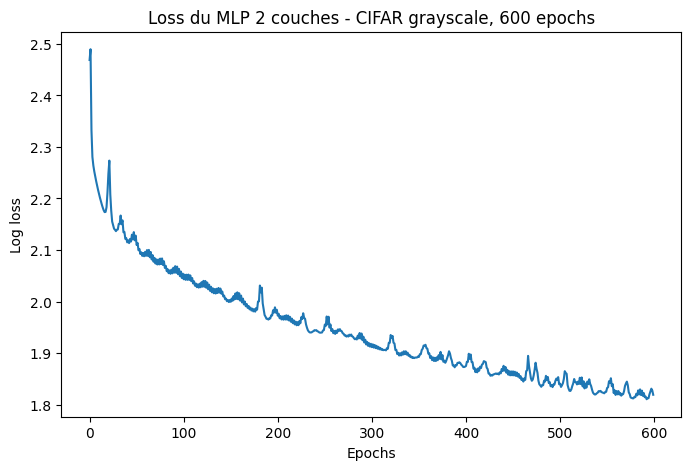

In [26]:
# =========================
# Loss du modèle final MLP 2 couches grayscale
# =========================

plt.figure(figsize=(8, 5))

plt.plot(loss_mlp2_gray_final)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du MLP 2 couches - CIFAR grayscale, 600 epochs")

plt.show()

Le MLP à deux couches cachées obtient le meilleur résultat sur les images en niveaux de gris, avec une accuracy test d'environ 35,5 %. Il améliore légèrement le MLP à une couche cachée, qui obtenait environ 34,5 %.

La courbe de loss reste un peu oscillante, mais elle diminue globalement jusqu'à la fin de l'entraînement. L'écart entre les accuracies train, validation et test reste faible, ce qui ne montre pas de fort overfitting.

Malgré cette amélioration, les performances restent assez limitées. Cela montre que les modèles entièrement connectés, appliqués sur des images aplaties en niveaux de gris, ne sont pas vraiment adaptés à CIFAR-10. La perte de l'information couleur et l'absence de prise en compte directe de la structure spatiale de l'image limitent fortement les résultats.

## 5. Deuxième étude : images en couleur RGB

Dans cette deuxième étude, on garde les trois composantes de couleur des images CIFAR-10.
Chaque image 32×32×3 est donc aplatie en un vecteur de taille 3072.

L'objectif est de voir si conserver l'information couleur améliore les résultats par rapport à la version en niveaux de gris.

### 5.1 Prétraitement des images RGB

In [28]:
# =========================
# Aplatissement RGB : 32 x 32 x 3 = 3072
# =========================

X_train_rgb_flat = X_train.reshape(X_train.shape[0], 32 * 32 * 3)
X_test_rgb_flat = X_test.reshape(X_test.shape[0], 32 * 32 * 3)

print("X_train_rgb_flat :", X_train_rgb_flat.shape)
print("X_test_rgb_flat :", X_test_rgb_flat.shape)

X_train_rgb_flat : (50000, 3072)
X_test_rgb_flat : (10000, 3072)


In [29]:
# =========================
# Split train / validation pour RGB
# =========================

X_train_rgb_sub, Y_train_rgb_sub, y_train_rgb_sub, X_valid_rgb, Y_valid_rgb, y_valid_rgb = create_train_valid_split(
    X_train_rgb_flat,
    Y_train,
    y_train,
    valid_size=5000
)

print("X_train_rgb_sub :", X_train_rgb_sub.shape)
print("Y_train_rgb_sub :", Y_train_rgb_sub.shape)
print("X_valid_rgb :", X_valid_rgb.shape)
print("Y_valid_rgb :", Y_valid_rgb.shape)

X_train_rgb_sub : (45000, 3072)
Y_train_rgb_sub : (45000, 10)
X_valid_rgb : (5000, 3072)
Y_valid_rgb : (5000, 10)


### 5.2 Modèle linéaire sur les images RGB

On commence par tester le modèle linéaire sur les images RGB.
Cette fois, on conserve les trois canaux de couleur, donc chaque image est représentée par un vecteur de taille 3072.

On s'attend à obtenir de meilleurs résultats qu'en niveaux de gris, car le modèle dispose de plus d'informations.


Learning rate : 0.05
Train accuracy : 0.29646666666666666
Validation accuracy : 0.2842
Final loss : 2.4593572523405234

Learning rate : 0.02
Train accuracy : 0.36017777777777776
Validation accuracy : 0.353
Final loss : 1.8723035505836163

Learning rate : 0.01
Train accuracy : 0.33926666666666666
Validation accuracy : 0.332
Final loss : 1.9370147298301876

Learning rate : 0.005
Train accuracy : 0.31346666666666667
Validation accuracy : 0.312
Final loss : 2.009727591164496


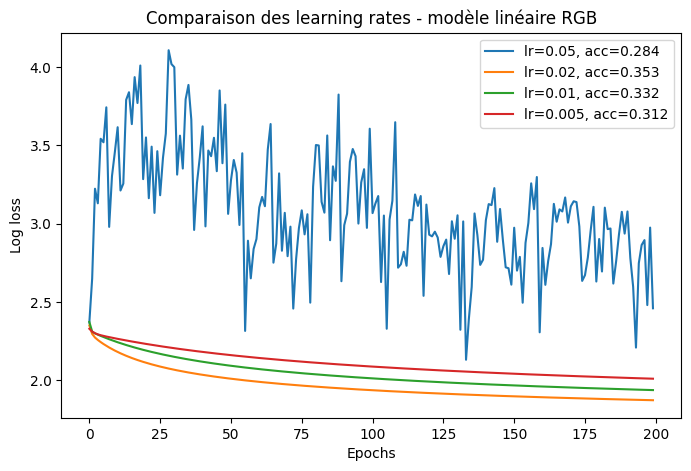

In [30]:
# =========================
# Test rapide des learning rates - modèle linéaire RGB
# =========================

learning_rates = [0.05, 0.02, 0.01, 0.005]

results_lr_linear_rgb = []

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    print("\n==============================")
    print("Learning rate :", lr)
    print("==============================")

    A_tmp, b_tmp, loss_tmp = train_linear_model(
        X_train_rgb_sub,
        Y_train_rgb_sub,
        input_dim=3072,
        num_classes=10,
        learning_rate=lr,
        epochs=200
    )

    y_pred_train_tmp = predict(X_train_rgb_sub, A_tmp, b_tmp)
    y_pred_valid_tmp = predict(X_valid_rgb, A_tmp, b_tmp)

    acc_train_tmp = accuracy(y_train_rgb_sub, y_pred_train_tmp)
    acc_valid_tmp = accuracy(y_valid_rgb, y_pred_valid_tmp)

    print("Train accuracy :", acc_train_tmp)
    print("Validation accuracy :", acc_valid_tmp)
    print("Final loss :", loss_tmp[-1])

    results_lr_linear_rgb.append({
        "learning_rate": lr,
        "train_accuracy": acc_train_tmp,
        "valid_accuracy": acc_valid_tmp,
        "final_loss": loss_tmp[-1],
        "A": A_tmp,
        "b": b_tmp,
        "loss_history": loss_tmp
    })

    plt.plot(loss_tmp, label=f"lr={lr}, acc={acc_valid_tmp:.3f}")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Comparaison des learning rates - modèle linéaire RGB")
plt.legend()
plt.show()

In [31]:
# =========================
# Modèle final linéaire RGB
# =========================

A_linear_rgb_final, b_linear_rgb_final, loss_linear_rgb_final = train_linear_model(
    X_train_rgb_sub,
    Y_train_rgb_sub,
    input_dim=3072,
    num_classes=10,
    learning_rate=0.02,
    epochs=600
)

# Accuracy train
y_pred_train_linear_rgb_final = predict(
    X_train_rgb_sub,
    A_linear_rgb_final,
    b_linear_rgb_final
)

acc_train_linear_rgb_final = accuracy(
    y_train_rgb_sub,
    y_pred_train_linear_rgb_final
)

# Accuracy validation
y_pred_valid_linear_rgb_final = predict(
    X_valid_rgb,
    A_linear_rgb_final,
    b_linear_rgb_final
)

acc_valid_linear_rgb_final = accuracy(
    y_valid_rgb,
    y_pred_valid_linear_rgb_final
)

# Accuracy test
y_pred_test_linear_rgb_final = predict(
    X_test_rgb_flat,
    A_linear_rgb_final,
    b_linear_rgb_final
)

acc_test_linear_rgb_final = accuracy(
    y_test,
    y_pred_test_linear_rgb_final
)

print("Train accuracy :", acc_train_linear_rgb_final)
print("Validation accuracy :", acc_valid_linear_rgb_final)
print("Test accuracy :", acc_test_linear_rgb_final)
print("Taux d'erreur test :", 1 - acc_test_linear_rgb_final)

Train accuracy : 0.3873333333333333
Validation accuracy : 0.375
Test accuracy : 0.3816
Taux d'erreur test : 0.6184000000000001


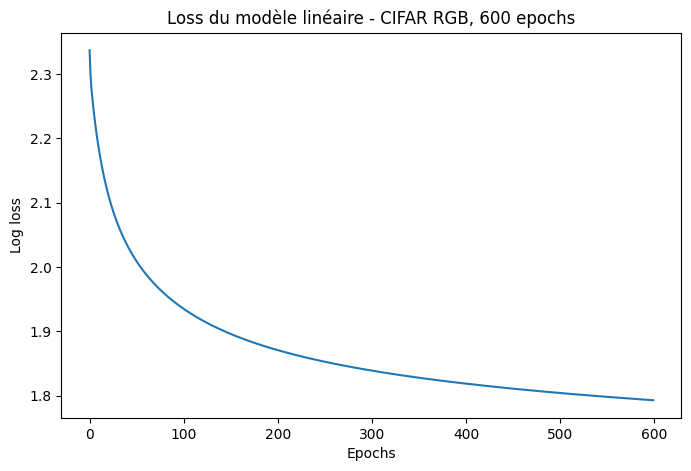

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(loss_linear_rgb_final)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du modèle linéaire - CIFAR RGB, 600 epochs")

plt.show()

Le modèle linéaire RGB atteint environ 38,2 % d'accuracy sur le test set. Ce résultat est meilleur que ceux obtenus avec les images en niveaux de gris, même avec les MLP. Cela montre que l'information couleur apporte une amélioration importante pour CIFAR-10.

La courbe de loss diminue régulièrement et l'écart entre train, validation et test reste faible. Le modèle généralise donc correctement, même si ses performances restent limitées car les images sont encore aplaties en vecteurs.

### 5.3 MLP à une couche cachée sur les images RGB

On teste maintenant un MLP à une couche cachée sur les images RGB.
Chaque image est toujours aplatie en un vecteur de taille 3072, mais l’ajout d’une couche cachée permet au modèle d’apprendre une transformation non linéaire des pixels.

On garde une approche simple : on teste quelques configurations raisonnables, puis on entraîne plus longtemps la meilleure.


hidden_dim=256, learning_rate=0.05
Train accuracy : 0.3950666666666667
Validation accuracy : 0.3882
Final loss : 1.7523457069149597

hidden_dim=512, learning_rate=0.05
Train accuracy : 0.38684444444444444
Validation accuracy : 0.378
Final loss : 1.7505112252345678

hidden_dim=512, learning_rate=0.02
Train accuracy : 0.37655555555555553
Validation accuracy : 0.366
Final loss : 1.8175636593185462


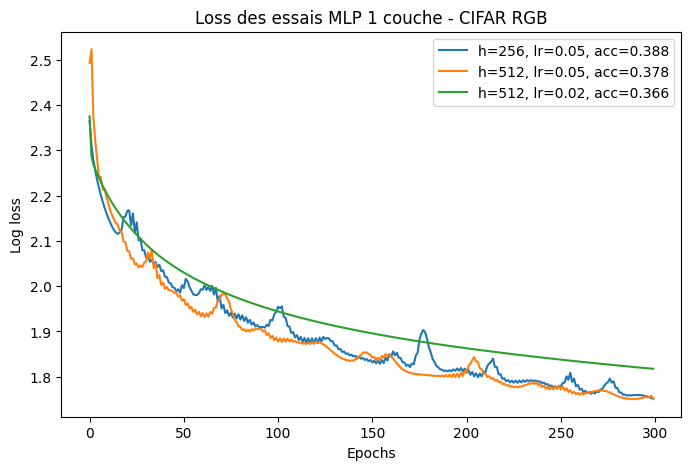

In [33]:
# =========================
# Tests rapides - MLP 1 couche RGB
# =========================

configs_mlp1_rgb = [
    {"hidden_dim": 256, "learning_rate": 0.05},
    {"hidden_dim": 512, "learning_rate": 0.05},
    {"hidden_dim": 512, "learning_rate": 0.02},
]

results_mlp1_rgb = []

plt.figure(figsize=(8, 5))

for config in configs_mlp1_rgb:
    hidden_dim = config["hidden_dim"]
    lr = config["learning_rate"]

    print("\n==============================")
    print(f"hidden_dim={hidden_dim}, learning_rate={lr}")
    print("==============================")

    A1, b1, A2, b2, loss_history = train_mlp_1_hidden(
        X_train_rgb_sub,
        Y_train_rgb_sub,
        input_dim=3072,
        hidden_dim=hidden_dim,
        num_classes=10,
        learning_rate=lr,
        epochs=300
    )

    y_pred_train = predict_1_hidden(
        X_train_rgb_sub,
        A1, b1,
        A2, b2
    )

    y_pred_valid = predict_1_hidden(
        X_valid_rgb,
        A1, b1,
        A2, b2
    )

    acc_train = accuracy(y_train_rgb_sub, y_pred_train)
    acc_valid = accuracy(y_valid_rgb, y_pred_valid)

    print("Train accuracy :", acc_train)
    print("Validation accuracy :", acc_valid)
    print("Final loss :", loss_history[-1])

    results_mlp1_rgb.append({
        "model": "MLP 1 hidden RGB",
        "hidden_dim": hidden_dim,
        "learning_rate": lr,
        "epochs": 300,
        "train_accuracy": acc_train,
        "valid_accuracy": acc_valid,
        "final_loss": loss_history[-1],
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2,
        "loss_history": loss_history
    })

    plt.plot(
        loss_history,
        label=f"h={hidden_dim}, lr={lr}, acc={acc_valid:.3f}"
    )

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des essais MLP 1 couche - CIFAR RGB")
plt.legend()
plt.show()

Augmenter le nombre de neurone ne semble pas necessaire et demande un temps de calcul bien superieur. Il faut cependant faire attention aux instabilites.

In [34]:
# =========================
# Modèle final MLP 1 couche RGB
# =========================

A1_mlp1_rgb_final, b1_mlp1_rgb_final, A2_mlp1_rgb_final, b2_mlp1_rgb_final, loss_mlp1_rgb_final = train_mlp_1_hidden(
    X_train_rgb_sub,
    Y_train_rgb_sub,
    input_dim=3072,
    hidden_dim=256,
    num_classes=10,
    learning_rate=0.05,
    epochs=600
)

# Accuracy train
y_pred_train_mlp1_rgb_final = predict_1_hidden(
    X_train_rgb_sub,
    A1_mlp1_rgb_final,
    b1_mlp1_rgb_final,
    A2_mlp1_rgb_final,
    b2_mlp1_rgb_final
)

acc_train_mlp1_rgb_final = accuracy(y_train_rgb_sub, y_pred_train_mlp1_rgb_final)

# Accuracy validation
y_pred_valid_mlp1_rgb_final = predict_1_hidden(
    X_valid_rgb,
    A1_mlp1_rgb_final,
    b1_mlp1_rgb_final,
    A2_mlp1_rgb_final,
    b2_mlp1_rgb_final
)

acc_valid_mlp1_rgb_final = accuracy(y_valid_rgb, y_pred_valid_mlp1_rgb_final)

# Accuracy test
y_pred_test_mlp1_rgb_final = predict_1_hidden(
    X_test_rgb_flat,
    A1_mlp1_rgb_final,
    b1_mlp1_rgb_final,
    A2_mlp1_rgb_final,
    b2_mlp1_rgb_final
)

acc_test_mlp1_rgb_final = accuracy(y_test, y_pred_test_mlp1_rgb_final)

print("Train accuracy :", acc_train_mlp1_rgb_final)
print("Validation accuracy :", acc_valid_mlp1_rgb_final)
print("Test accuracy :", acc_test_mlp1_rgb_final)
print("Taux d'erreur test :", 1 - acc_test_mlp1_rgb_final)

Train accuracy : 0.4225111111111111
Validation accuracy : 0.4098
Test accuracy : 0.4137
Taux d'erreur test : 0.5863


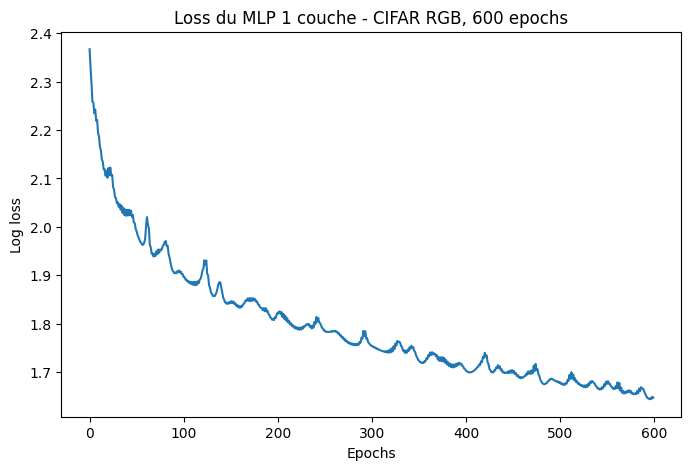

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(loss_mlp1_rgb_final)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du MLP 1 couche - CIFAR RGB, 600 epochs")

plt.show()

Le MLP à une couche cachée sur les images RGB atteint environ 41,4 % d'accuracy sur le test set. Il améliore nettement le modèle linéaire RGB, qui était autour de 38,2 %. La courbe de loss diminue globalement et l'écart entre train, validation et test reste faible, ce qui ne montre pas de fort overfitting.

Ce résultat confirme que l'ajout d'une couche cachée permet d'apprendre une représentation plus utile que le modèle linéaire. Cependant, les performances restent limitées car les images sont toujours aplaties en vecteurs et la structure spatiale n'est pas directement exploitée.

### 5.4 MLP à deux couches cachées sur les images RGB

On teste maintenant un MLP avec deux couches cachées sur les images RGB.
L'objectif est de voir si l'ajout d'une deuxième couche permet d'améliorer le MLP à une couche cachée.

Comme l'entraînement est plus long, on ne fait pas une recherche complète. On teste quelques configurations simples, puis on garde la meilleure.


h1=512, h2=128, learning_rate=0.05
Train accuracy : 0.4136222222222222
Validation accuracy : 0.4002
Final loss : 1.6664094375781675

h1=512, h2=256, learning_rate=0.05
Train accuracy : 0.4151111111111111
Validation accuracy : 0.4012
Final loss : 1.6641157037372456


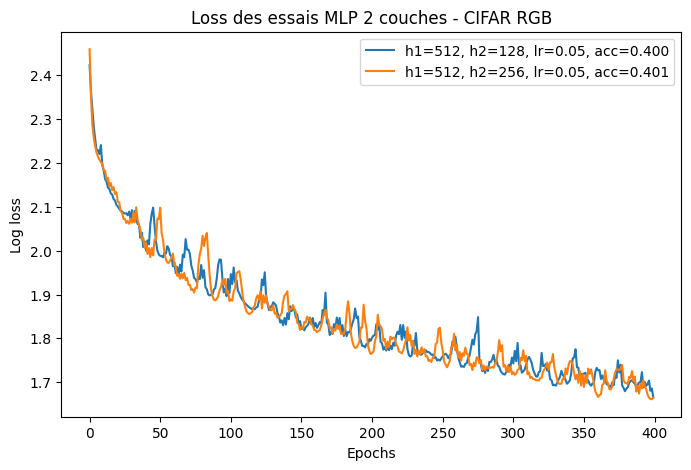

In [36]:
# =========================
# Tests rapides - MLP 2 couches RGB
# =========================

configs_mlp2_rgb = [
    {"hidden_dim1": 512, "hidden_dim2": 128, "learning_rate": 0.05},
    {"hidden_dim1": 512, "hidden_dim2": 256, "learning_rate": 0.05},
]

results_mlp2_rgb = []

plt.figure(figsize=(8, 5))

for config in configs_mlp2_rgb:
    hidden_dim1 = config["hidden_dim1"]
    hidden_dim2 = config["hidden_dim2"]
    lr = config["learning_rate"]

    print("\n==============================")
    print(f"h1={hidden_dim1}, h2={hidden_dim2}, learning_rate={lr}")
    print("==============================")

    A1, b1, A2, b2, A3, b3, loss_history = train_mlp_2_hidden(
        X_train_rgb_sub,
        Y_train_rgb_sub,
        input_dim=3072,
        hidden_dim1=hidden_dim1,
        hidden_dim2=hidden_dim2,
        num_classes=10,
        learning_rate=lr,
        epochs=400
    )

    y_pred_train = predict_2_hidden(
        X_train_rgb_sub,
        A1, b1,
        A2, b2,
        A3, b3
    )

    y_pred_valid = predict_2_hidden(
        X_valid_rgb,
        A1, b1,
        A2, b2,
        A3, b3
    )

    acc_train = accuracy(y_train_rgb_sub, y_pred_train)
    acc_valid = accuracy(y_valid_rgb, y_pred_valid)

    print("Train accuracy :", acc_train)
    print("Validation accuracy :", acc_valid)
    print("Final loss :", loss_history[-1])

    results_mlp2_rgb.append({
        "model": "MLP 2 hidden RGB",
        "hidden_dim1": hidden_dim1,
        "hidden_dim2": hidden_dim2,
        "learning_rate": lr,
        "epochs": 400,
        "train_accuracy": acc_train,
        "valid_accuracy": acc_valid,
        "final_loss": loss_history[-1],
        "A1": A1,
        "b1": b1,
        "A2": A2,
        "b2": b2,
        "A3": A3,
        "b3": b3,
        "loss_history": loss_history
    })

    plt.plot(
        loss_history,
        label=f"h1={hidden_dim1}, h2={hidden_dim2}, lr={lr}, acc={acc_valid:.3f}"
    )

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des essais MLP 2 couches - CIFAR RGB")
plt.legend()
plt.show()

In [37]:
# =========================
# Modèle final MLP 2 couches RGB
# =========================

A1_mlp2_rgb_final, b1_mlp2_rgb_final, A2_mlp2_rgb_final, b2_mlp2_rgb_final, A3_mlp2_rgb_final, b3_mlp2_rgb_final, loss_mlp2_rgb_final = train_mlp_2_hidden(
    X_train_rgb_sub,
    Y_train_rgb_sub,
    input_dim=3072,
    hidden_dim1=512,
    hidden_dim2=256,
    num_classes=10,
    learning_rate=0.05,
    epochs=600
)

# Accuracy train
y_pred_train_mlp2_rgb_final = predict_2_hidden(
    X_train_rgb_sub,
    A1_mlp2_rgb_final,
    b1_mlp2_rgb_final,
    A2_mlp2_rgb_final,
    b2_mlp2_rgb_final,
    A3_mlp2_rgb_final,
    b3_mlp2_rgb_final
)

acc_train_mlp2_rgb_final = accuracy(y_train_rgb_sub, y_pred_train_mlp2_rgb_final)

# Accuracy validation
y_pred_valid_mlp2_rgb_final = predict_2_hidden(
    X_valid_rgb,
    A1_mlp2_rgb_final,
    b1_mlp2_rgb_final,
    A2_mlp2_rgb_final,
    b2_mlp2_rgb_final,
    A3_mlp2_rgb_final,
    b3_mlp2_rgb_final
)

acc_valid_mlp2_rgb_final = accuracy(y_valid_rgb, y_pred_valid_mlp2_rgb_final)

# Accuracy test
y_pred_test_mlp2_rgb_final = predict_2_hidden(
    X_test_rgb_flat,
    A1_mlp2_rgb_final,
    b1_mlp2_rgb_final,
    A2_mlp2_rgb_final,
    b2_mlp2_rgb_final,
    A3_mlp2_rgb_final,
    b3_mlp2_rgb_final
)

acc_test_mlp2_rgb_final = accuracy(y_test, y_pred_test_mlp2_rgb_final)

print("Train accuracy :", acc_train_mlp2_rgb_final)
print("Validation accuracy :", acc_valid_mlp2_rgb_final)
print("Test accuracy :", acc_test_mlp2_rgb_final)
print("Taux d'erreur test :", 1 - acc_test_mlp2_rgb_final)

Train accuracy : 0.4332666666666667
Validation accuracy : 0.417
Test accuracy : 0.4237
Taux d'erreur test : 0.5763


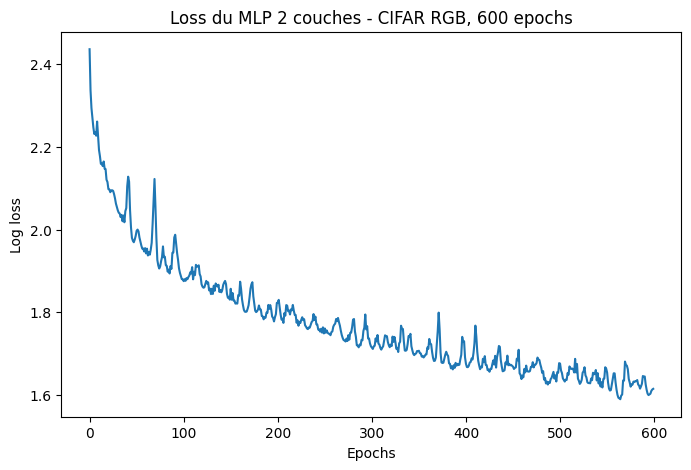

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(loss_mlp2_rgb_final)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du MLP 2 couches - CIFAR RGB, 600 epochs")

plt.show()

Le MLP à deux couches cachées sur les images RGB atteint environ 42,4 % d'accuracy sur le test set. Il améliore légèrement le MLP à une couche cachée, qui obtenait environ 41,4 %. La loss diminue globalement, même si elle reste un peu oscillante.

Ce modèle est le meilleur parmi les architectures entièrement connectées testées sur CIFAR-10. Cependant, les performances restent limitées par rapport à MNIST, car les images CIFAR-10 sont plus complexes et sont encore aplaties en vecteurs. Le modèle ne prend donc pas directement en compte la structure spatiale locale de l'image, contrairement à un réseau convolutif.

## 6. Sauvegarde des meilleurs modèles

In [40]:
# =========================
# Sauvegarde des meilleurs modèles CIFAR-10
# =========================

import pickle

best_models_cifar = {
    "linear_gray": {
        "A": A_gray,
        "b": b_gray,
        "loss_history": loss_linear_gray,
        "train_accuracy": acc_train_linear_gray,
        "valid_accuracy": acc_valid_linear_gray,
        "test_accuracy": acc_test_linear_gray,
        "learning_rate": 0.05,
        "epochs": 400,
        "input_dim": 1024
    },

    "mlp1_gray": {
        "A1": A1_test2,
        "b1": b1_test2,
        "A2": A2_test2,
        "b2": b2_test2,
        "loss_history": loss_test2,
        "train_accuracy": acc_train_test2,
        "valid_accuracy": acc_valid_test2,
        "test_accuracy": acc_test_test2,
        "hidden_dim": 512,
        "learning_rate": 0.1,
        "epochs": 600,
        "input_dim": 1024
    },

    "mlp2_gray": {
        "A1": A1_mlp2_gray_final,
        "b1": b1_mlp2_gray_final,
        "A2": A2_mlp2_gray_final,
        "b2": b2_mlp2_gray_final,
        "A3": A3_mlp2_gray_final,
        "b3": b3_mlp2_gray_final,
        "loss_history": loss_mlp2_gray_final,
        "train_accuracy": acc_train_mlp2_gray_final,
        "valid_accuracy": acc_valid_mlp2_gray_final,
        "test_accuracy": acc_test_mlp2_gray_final,
        "hidden_dim1": 512,
        "hidden_dim2": 128,
        "learning_rate": 0.1,
        "epochs": 600,
        "input_dim": 1024
    },

    "linear_rgb": {
        "A": A_linear_rgb_final,
        "b": b_linear_rgb_final,
        "loss_history": loss_linear_rgb_final,
        "train_accuracy": acc_train_linear_rgb_final,
        "valid_accuracy": acc_valid_linear_rgb_final,
        "test_accuracy": acc_test_linear_rgb_final,
        "learning_rate": 0.02,
        "epochs": 600,
        "input_dim": 3072
    },

    "mlp1_rgb": {
        "A1": A1_mlp1_rgb_final,
        "b1": b1_mlp1_rgb_final,
        "A2": A2_mlp1_rgb_final,
        "b2": b2_mlp1_rgb_final,
        "loss_history": loss_mlp1_rgb_final,
        "train_accuracy": acc_train_mlp1_rgb_final,
        "valid_accuracy": acc_valid_mlp1_rgb_final,
        "test_accuracy": acc_test_mlp1_rgb_final,
        "hidden_dim": 256,
        "learning_rate": 0.05,
        "epochs": 600,
        "input_dim": 3072
    },

    "mlp2_rgb": {
        "A1": A1_mlp2_rgb_final,
        "b1": b1_mlp2_rgb_final,
        "A2": A2_mlp2_rgb_final,
        "b2": b2_mlp2_rgb_final,
        "A3": A3_mlp2_rgb_final,
        "b3": b3_mlp2_rgb_final,
        "loss_history": loss_mlp2_rgb_final,
        "train_accuracy": acc_train_mlp2_rgb_final,
        "valid_accuracy": acc_valid_mlp2_rgb_final,
        "test_accuracy": acc_test_mlp2_rgb_final,
        "hidden_dim1": 512,
        "hidden_dim2": 256,
        "learning_rate": 0.05,
        "epochs": 600,
        "input_dim": 3072
    }
}

with open("best_models_cifar.pkl", "wb") as f:
    pickle.dump(best_models_cifar, f)

print("Meilleurs modèles CIFAR sauvegardés dans best_models_cifar.pkl")

Meilleurs modèles CIFAR sauvegardés dans best_models_cifar.pkl


In [41]:
# =========================
# Rechargement test
# =========================

with open("best_models_cifar.pkl", "rb") as f:
    loaded_best_models_cifar = pickle.load(f)

loaded_best_models_cifar.keys()

dict_keys(['linear_gray', 'mlp1_gray', 'mlp2_gray', 'linear_rgb', 'mlp1_rgb', 'mlp2_rgb'])

In [42]:
for model_name, model_data in loaded_best_models_cifar.items():
    print(model_name)
    print("Train accuracy :", model_data["train_accuracy"])
    print("Validation accuracy :", model_data["valid_accuracy"])
    print("Test accuracy :", model_data["test_accuracy"])
    print()

linear_gray
Train accuracy : 0.2950888888888889
Validation accuracy : 0.2928
Test accuracy : 0.2935

mlp1_gray
Train accuracy : 0.35388888888888886
Validation accuracy : 0.3436
Test accuracy : 0.3451

mlp2_gray
Train accuracy : 0.36295555555555553
Validation accuracy : 0.3582
Test accuracy : 0.3552

linear_rgb
Train accuracy : 0.3873333333333333
Validation accuracy : 0.375
Test accuracy : 0.3816

mlp1_rgb
Train accuracy : 0.4225111111111111
Validation accuracy : 0.4098
Test accuracy : 0.4137

mlp2_rgb
Train accuracy : 0.4332666666666667
Validation accuracy : 0.417
Test accuracy : 0.4237



## 7. Comparaison finale des modèles

Dans cette partie, on compare les différents modèles testés sur CIFAR-10.
On sépare les résultats obtenus avec les images en niveaux de gris et ceux obtenus avec les images RGB.

L'objectif est de voir l'effet de l'information couleur, mais aussi l'effet de la complexité du modèle.

In [43]:
# =========================
# Tableau récapitulatif final CIFAR-10
# =========================

comparison_cifar = pd.DataFrame([
    {
        "Données": "Grayscale",
        "Modèle": "Linéaire",
        "Train accuracy": acc_train_linear_gray,
        "Validation accuracy": acc_valid_linear_gray,
        "Test accuracy": acc_test_linear_gray,
        "Taux d'erreur test": 1 - acc_test_linear_gray,
        "Learning rate": 0.05,
        "Epochs": 400,
        "Hidden dim": None,
        "Hidden dim 1": None,
        "Hidden dim 2": None
    },
    {
        "Données": "Grayscale",
        "Modèle": "MLP 1 couche",
        "Train accuracy": acc_train_test2,
        "Validation accuracy": acc_valid_test2,
        "Test accuracy": acc_test_test2,
        "Taux d'erreur test": 1 - acc_test_test2,
        "Learning rate": 0.1,
        "Epochs": 600,
        "Hidden dim": 512,
        "Hidden dim 1": None,
        "Hidden dim 2": None
    },
    {
        "Données": "Grayscale",
        "Modèle": "MLP 2 couches",
        "Train accuracy": acc_train_mlp2_gray_final,
        "Validation accuracy": acc_valid_mlp2_gray_final,
        "Test accuracy": acc_test_mlp2_gray_final,
        "Taux d'erreur test": 1 - acc_test_mlp2_gray_final,
        "Learning rate": 0.1,
        "Epochs": 600,
        "Hidden dim": None,
        "Hidden dim 1": 512,
        "Hidden dim 2": 128
    },
    {
        "Données": "RGB",
        "Modèle": "Linéaire",
        "Train accuracy": acc_train_linear_rgb_final,
        "Validation accuracy": acc_valid_linear_rgb_final,
        "Test accuracy": acc_test_linear_rgb_final,
        "Taux d'erreur test": 1 - acc_test_linear_rgb_final,
        "Learning rate": 0.02,
        "Epochs": 600,
        "Hidden dim": None,
        "Hidden dim 1": None,
        "Hidden dim 2": None
    },
    {
        "Données": "RGB",
        "Modèle": "MLP 1 couche",
        "Train accuracy": acc_train_mlp1_rgb_final,
        "Validation accuracy": acc_valid_mlp1_rgb_final,
        "Test accuracy": acc_test_mlp1_rgb_final,
        "Taux d'erreur test": 1 - acc_test_mlp1_rgb_final,
        "Learning rate": 0.05,
        "Epochs": 600,
        "Hidden dim": 256,
        "Hidden dim 1": None,
        "Hidden dim 2": None
    },
    {
        "Données": "RGB",
        "Modèle": "MLP 2 couches",
        "Train accuracy": acc_train_mlp2_rgb_final,
        "Validation accuracy": acc_valid_mlp2_rgb_final,
        "Test accuracy": acc_test_mlp2_rgb_final,
        "Taux d'erreur test": 1 - acc_test_mlp2_rgb_final,
        "Learning rate": 0.05,
        "Epochs": 600,
        "Hidden dim": None,
        "Hidden dim 1": 512,
        "Hidden dim 2": 256
    }
])

comparison_cifar_rounded = comparison_cifar.copy()

for col in ["Train accuracy", "Validation accuracy", "Test accuracy", "Taux d'erreur test"]:
    comparison_cifar_rounded[col] = comparison_cifar_rounded[col].round(4)

comparison_cifar_rounded

,Données,Modèle,Train accuracy,Validation accuracy,Test accuracy,Taux d'erreur test,Learning rate,Epochs,Hidden dim,Hidden dim 1,Hidden dim 2
0,Grayscale,Linéaire,0.2951,0.2928,0.2935,0.7065,0.05,400,NaN,NaN,NaN
1,Grayscale,MLP 1 couche,0.3539,0.3436,0.3451,0.6549,0.10,600,512.0,NaN,NaN
2,Grayscale,MLP 2 couches,0.3630,0.3582,0.3552,0.6448,0.10,600,NaN,512.0,128.0
3,RGB,Linéaire,0.3873,0.3750,0.3816,0.6184,0.02,600,NaN,NaN,NaN
4,RGB,MLP 1 couche,0.4225,0.4098,0.4137,0.5863,0.05,600,256.0,NaN,NaN
5,RGB,MLP 2 couches,0.4333,0.4170,0.4237,0.5763,0.05,600,NaN,512.0,256.0


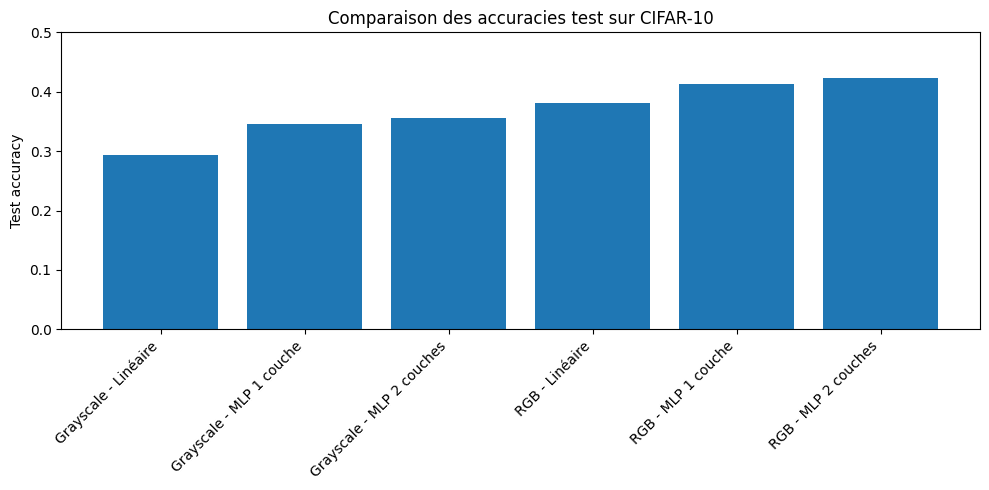

In [44]:
# =========================
# Graphique des accuracies test
# =========================

plt.figure(figsize=(10, 5))

labels = comparison_cifar_rounded["Données"] + " - " + comparison_cifar_rounded["Modèle"]

plt.bar(labels, comparison_cifar_rounded["Test accuracy"])

plt.ylabel("Test accuracy")
plt.title("Comparaison des accuracies test sur CIFAR-10")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 0.5)

plt.tight_layout()
plt.show()

Les résultats montrent que les modèles RGB obtiennent de meilleures performances que les modèles en niveaux de gris. Cela confirme que l'information couleur est utile pour CIFAR-10.

On observe aussi que les MLP améliorent les résultats par rapport au modèle linéaire. Le meilleur modèle est le MLP à deux couches cachées sur les images RGB, avec environ 42,4 % d'accuracy test.

Cependant, les performances restent nettement plus faibles que sur MNIST. Cela s'explique par la complexité de CIFAR-10 : les images représentent des objets réels, avec des fonds variés, des positions différentes et beaucoup plus de détails. De plus, nos modèles utilisent encore des images aplaties en vecteurs, ce qui ne permet pas d'exploiter directement la structure spatiale de l'image.